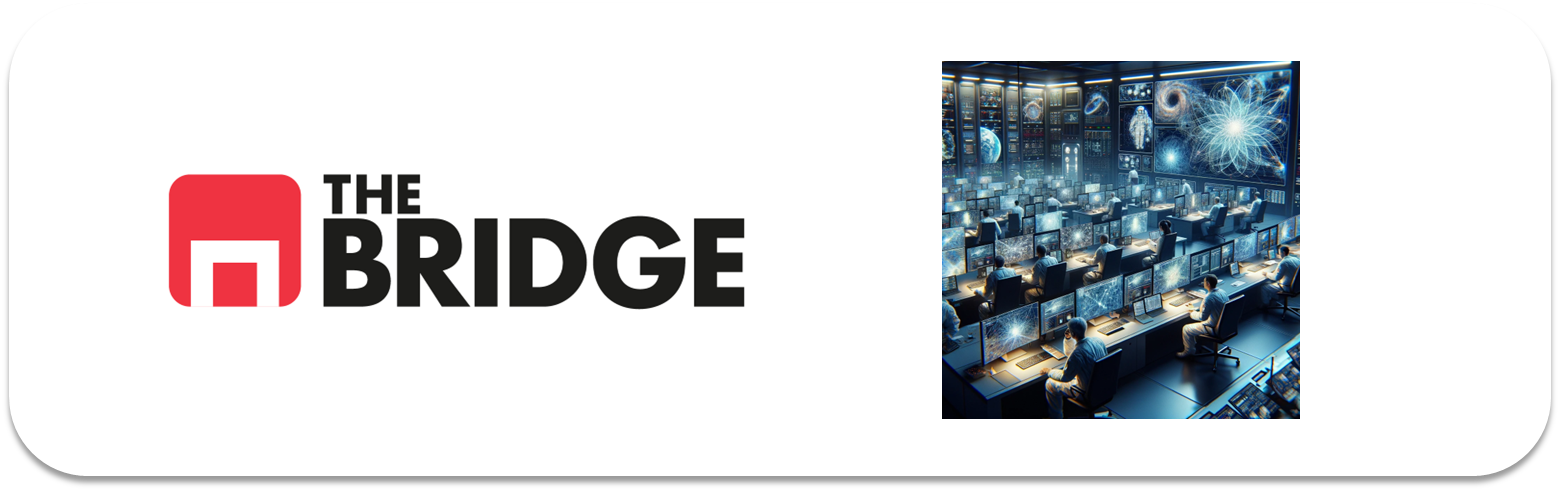

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [5]:
# Tamaño al que redimensionaremos todas las imágenes (32x32 píxeles)
IMG_SIZE = 32

# Directorios de entrenamiento (4 carpetas con 1000 imágenes cada una)
TRAIN_DIRS = ["data/github_train_0", "data/github_train_1", "data/github_train_2", "data/github_train_3"]

# Directorio de test (imágenes a clasificar)
TEST_DIR = "data/github_test"


def cargar_imagenes(directorios, img_size=IMG_SIZE):
    """
    Lee todas las imágenes de uno o varios directorios, las redimensiona
    y extrae la clase (cat/dog) a partir del nombre del archivo.

    Devuelve:
        X: array de imágenes (num_imagenes, img_size, img_size, 3)
        y: array de etiquetas ("cat" o "dog")
        filenames: lista con los nombres de archivo originales (útil luego
                   para identificar imágenes concretas, ej. en el Ejercicio 5)
    """
    # Permite pasar un único directorio (string) o una lista de directorios
    if isinstance(directorios, str):
        directorios = [directorios]

    X, y, filenames = [], [], []

    for d in directorios:
        for fname in os.listdir(d):
            # Nos aseguramos de que solo procesamos archivos de imagen
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            # Leemos la imagen (cv2 la carga en formato BGR por defecto)
            img = cv2.imread(os.path.join(d, fname))

            # Convertimos de BGR a RGB (el formato "normal" para visualizar y para Keras)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Redimensionamos a 32x32 para que todas las imágenes tengan el mismo tamaño
            img = cv2.resize(img, (img_size, img_size))

            X.append(img)

            # La clase está en el nombre del archivo: "cat.1000.jpg" -> "cat"
            y.append(fname.split(".")[0])

            filenames.append(fname)

    return np.array(X), np.array(y), filenames


# Cargamos train (las 4 carpetas juntas) y test
X_train, y_train, files_train = cargar_imagenes(TRAIN_DIRS)
X_test, y_test, files_test = cargar_imagenes(TEST_DIR)

# Comprobamos las dimensiones
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4000, 32, 32, 3) (4000,)
(1000, 32, 32, 3) (1000,)


{np.str_('cat'): np.int64(2000), np.str_('dog'): np.int64(2000)}


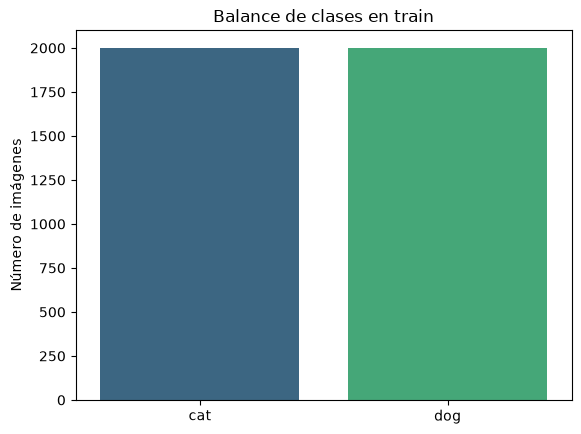

In [6]:
# --- MiniEDA: balance de clases ---
clases, conteos = np.unique(y_train, return_counts=True)
print(dict(zip(clases, conteos)))

sns.barplot(x=clases, y=conteos, hue=clases, palette="viridis", legend=False)
plt.title("Balance de clases en train")
plt.ylabel("Número de imágenes")
plt.show()

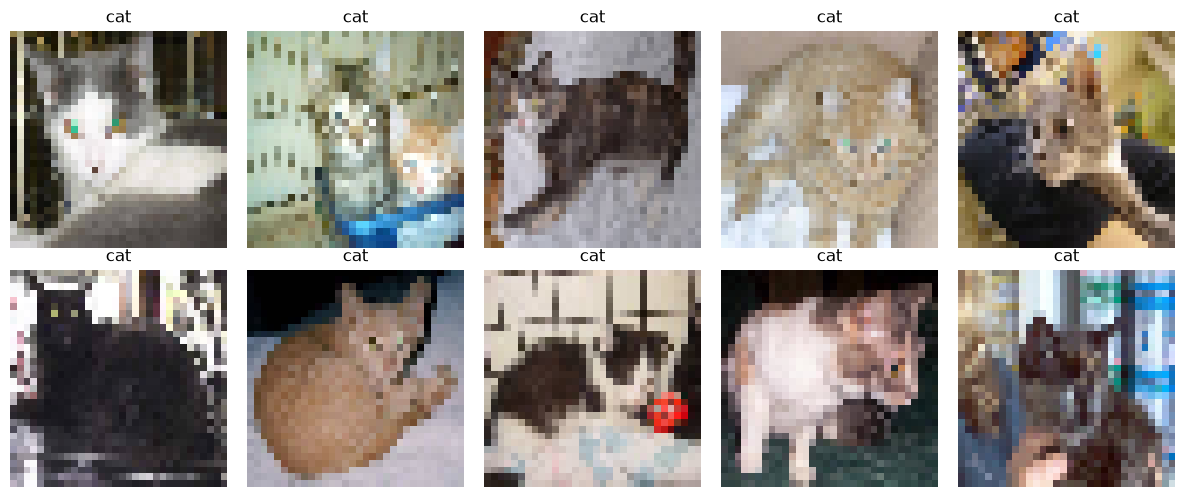

In [7]:
# --- MiniEDA: muestra visual de algunas imágenes ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(y_train[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# --- Preprocesado ---

# Normalizamos los píxeles a rango [0,1] (originalmente están en [0,255])
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Convertimos las etiquetas de texto ("cat"/"dog") a números (0/1) para el modelo
# dog -> 1, cat -> 0
y_train_num = (y_train == "dog").astype("int32")
y_test_num = (y_test == "dog").astype("int32")

print(X_train_norm.shape, y_train_num[:10])

(4000, 32, 32, 3) [0 0 0 0 0 0 0 0 0 0]


In [13]:
# --- Construcción del modelo CNN ---
# Al menos 2 bloques Convolucional + Pooling, como pide el enunciado

model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Bloque 1: detecta patrones simples (bordes, texturas)
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Bloque 2: combina lo anterior en patrones más complejos
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Aplanamos para pasar a las capas densas
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),  # evita overfitting

    # Salida: clasificación binaria (cat=0, dog=1) -> sigmoid + 1 neurona
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# EarlyStopping: para el entrenamiento si val_loss deja de mejorar,
# y se queda con los mejores pesos vistos (restore_best_weights)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_norm, y_train_num,
    epochs=50,              # ponemos un número alto, EarlyStopping cortará antes si hace falta
    batch_size=32,
    validation_split=0.2,   # 20% de train para validación durante el entrenamiento
    callbacks=[early_stop]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6100 - loss: 0.6758 - val_accuracy: 0.0000e+00 - val_loss: 0.9257
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6253 - loss: 0.6555 - val_accuracy: 0.0000e+00 - val_loss: 0.8954
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6319 - loss: 0.6403 - val_accuracy: 0.3950 - val_loss: 0.7990
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6666 - loss: 0.6088 - val_accuracy: 0.0887 - val_loss: 1.0995
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6759 - loss: 0.5941 - val_accuracy: 0.6350 - val_loss: 0.6938
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6997 - loss: 0.5760 - val_accuracy: 0.4475 - val_loss: 0.8393
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7337 - loss: 0.5366 - val_accuracy: 0.4975 - val_loss: 0.8010
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7475 - loss: 0.5180 - val_accu

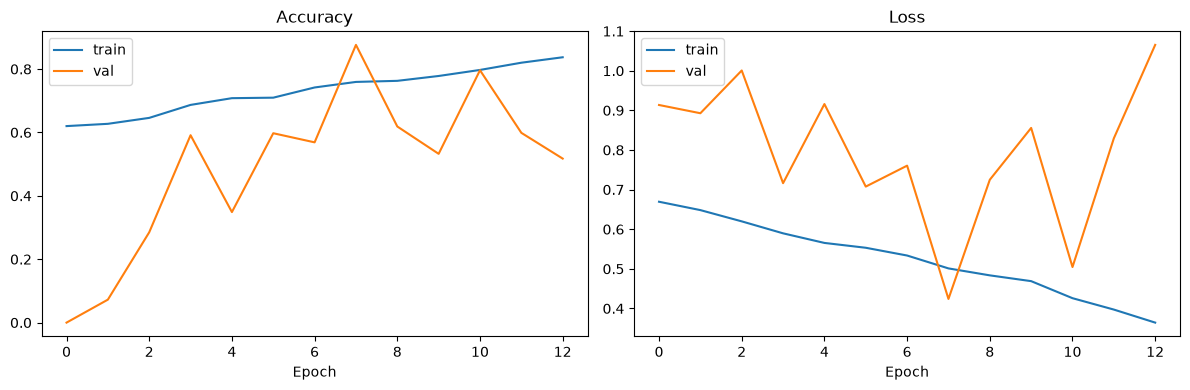

In [11]:
# --- Historial de entrenamiento ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm, y_train_num,
    test_size=0.2,
    stratify=y_train_num,   # mantiene la proporción cat/dog en train y val
    random_state=42,
    shuffle=True
)

In [15]:
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7628 - loss: 0.5000 - val_accuracy: 0.7825 - val_loss: 0.4620
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7759 - loss: 0.4850 - val_accuracy: 0.7375 - val_loss: 0.5103
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7719 - loss: 0.4756 - val_accuracy: 0.7487 - val_loss: 0.5092
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7847 - loss: 0.4560 - val_accuracy: 0.7837 - val_loss: 0.4539
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8153 - loss: 0.4135 - val_accuracy: 0.7763 - val_loss: 0.4727
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8172 - loss: 0.4030 - val_accuracy: 0.7950 - val_loss: 0.4511
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8300 - loss: 0.3678 - val_accuracy: 0.8012 - val_loss: 0.4620
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8506 - loss: 0.3485 - val_accuracy: 0.

In [16]:
# --- Predicciones sobre el conjunto de test ---
y_pred_proba = model.predict(X_test_norm)   # probabilidades (entre 0 y 1) de ser "dog"
y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

# --- Classification report ---
print(classification_report(y_test_num, y_pred, target_names=["cat", "dog"]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

         cat       0.73      0.79      0.76       500
         dog       0.77      0.71      0.74       500

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75      0.75      1000



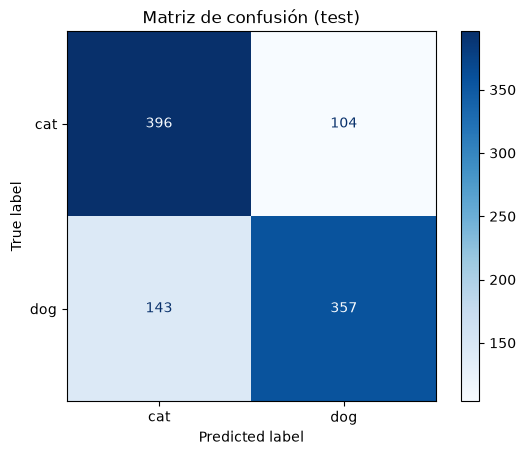

In [17]:
# --- Matriz de confusión ---
cm = confusion_matrix(y_test_num, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión (test)")
plt.show()

In [18]:
# Probabilidad de "dog" para cada imagen de test (aplanamos el array)
proba = y_pred_proba.flatten()

# --- Perros clasificados como gatos ---
# True label = dog (1), predicción = cat (0)
mask_dog_as_cat = (y_test_num == 1) & (y_pred == 0)
idx_dog_as_cat = np.where(mask_dog_as_cat)[0]

# Confianza en el error (predijo "cat") = 1 - P(dog). Cuanto más baja P(dog), más seguro estaba de que era cat.
confianza_dog_as_cat = 1 - proba[idx_dog_as_cat]

n_dog = max(1, round(len(idx_dog_as_cat) * 0.10))
top_dog_as_cat = idx_dog_as_cat[np.argsort(-confianza_dog_as_cat)][:n_dog]

# --- Gatos clasificados como perros ---
mask_cat_as_dog = (y_test_num == 0) & (y_pred == 1)
idx_cat_as_dog = np.where(mask_cat_as_dog)[0]

# Confianza en el error (predijo "dog") = P(dog) directamente
confianza_cat_as_dog = proba[idx_cat_as_dog]

n_cat = max(1, round(len(idx_cat_as_dog) * 0.10))
top_cat_as_dog = idx_cat_as_dog[np.argsort(-confianza_cat_as_dog)][:n_cat]

print(f"Perros→gatos: {len(idx_dog_as_cat)} mal clasificados, seleccionamos {n_dog}")
print(f"Gatos→perros: {len(idx_cat_as_dog)} mal clasificados, seleccionamos {n_cat}")

Perros→gatos: 143 mal clasificados, seleccionamos 14
Gatos→perros: 104 mal clasificados, seleccionamos 10


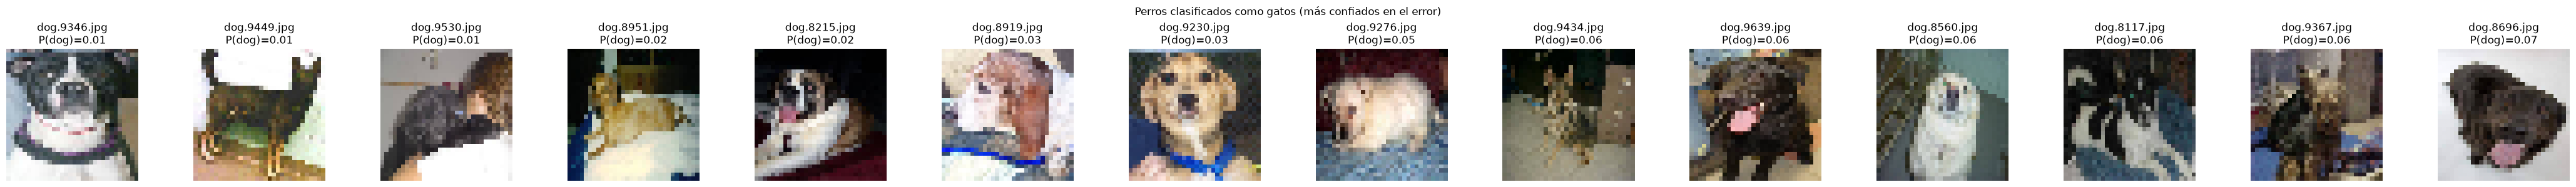

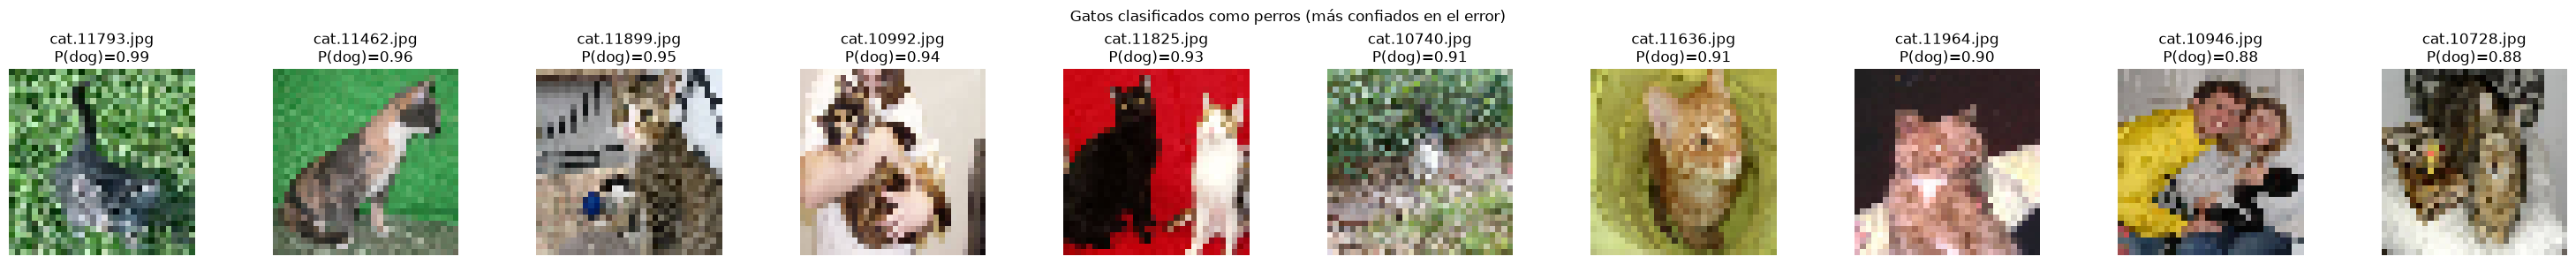

In [19]:
# --- Visualización de la selección ---
def mostrar_seleccion(indices, titulo):
    n = len(indices)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(X_test[idx])
        ax.set_title(f"{files_test[idx]}\nP(dog)={proba[idx]:.2f}")
        ax.axis("off")
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

mostrar_seleccion(top_dog_as_cat, "Perros clasificados como gatos (más confiados en el error)")
mostrar_seleccion(top_cat_as_dog, "Gatos clasificados como perros (más confiados en el error)")